# Independent Tripp Standardization: Pantheon+ vs Union3

Fit Tripp's relation $\mu = m_B - M_B + \alpha x_1 - \beta c$ independently to Pantheon+ and Union3, compute standardized distance moduli, and compare residuals and inter-survey differences as a function of redshift.

**Reference cosmology:** Flat $\Lambda$CDM ($H_0 = 70$, $\Omega_m = 0.3$)

**Note:** No host-mass correction is applied — this is pure Tripp only.

In [36]:
import sys, os, pickle, gzip, pathlib, warnings
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation as mad
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

mpl.rcParams.update({
    "font.family": "serif", "font.size": 11,
    "axes.labelsize": 12, "axes.titlesize": 13,
    "legend.fontsize": 9, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "lines.linewidth": 1.5, "axes.grid": True, "grid.alpha": 0.3,
})

DATA = pathlib.Path("..") / "data"
C_PAN = "#1f77b4"
C_U3 = "#2ca02c"
print("Setup complete.")

Setup complete.


In [37]:
with gzip.open(DATA / "analysis/hubble_data.pklz", "rb") as f:
    d = pickle.load(f)

hd = d["hd"]
cosmo = d["cosmo"]

pan = hd[hd["survey"] == "Pantheon+"].copy().reset_index(drop=True)
u3  = hd[hd["survey"] == "Union3"].copy().reset_index(drop=True)

print(f"Pantheon+: {len(pan)} SNe   (z range: {pan['z'].min():.4f} - {pan['z'].max():.4f})")
print(f"Union3:    {len(u3)} SNe   (z range: {u3['z'].min():.4f} - {u3['z'].max():.4f})")
print(f"Reference LCDM: H0={cosmo.H0.value:.0f}, Om0={cosmo.Om0:.1f}")

Pantheon+: 1543 SNe   (z range: 0.0012 - 2.2614)
Union3:    2087 SNe   (z range: 0.0093 - 2.2600)
Reference LCDM: H0=70, Om0=0.3


## Independent Tripp Fit

For each survey, we fit:
$$ Y \equiv m_B - \mu_{\rm LCDM}(z) = M - \alpha x_1 + \beta c $$

via ordinary least squares. The design matrix is $[\mathbb{1},\, -x_1,\, c]$.

In [38]:
def fit_tripp(sub):
    n = len(sub)
    Y = sub["Y"].values.astype(float)
    X = np.column_stack([np.ones(n), -sub["x1"].values.astype(float), sub["c"].values.astype(float)])
    coeffs, resid, rank, s = np.linalg.lstsq(X, Y, rcond=None)
    M, alpha, beta = coeffs
    resid_std = np.std(Y - X @ coeffs)
    return M, alpha, beta, resid_std

M_pan, a_pan, b_pan, r_pan = fit_tripp(pan)
M_u3,  a_u3,  b_u3,  r_u3  = fit_tripp(u3)

print("=" * 60)
print("INDEPENDENT TRIPP FIT RESULTS")
print("=" * 60)
print(f"{'Survey':12s} {'M_B':>9s} {'alpha':>8s} {'beta':>8s} {'std_resid':>10s} {'N':>6s}")
print("  " + "-" * 53)
print(f"{'Pantheon+':12s} {M_pan:>+9.4f} {a_pan:>+8.4f} {b_pan:>+8.4f} {r_pan:>10.4f} {len(pan):>6d}")
print(f"{'Union3':12s}    {M_u3:>+9.4f} {a_u3:>+8.4f} {b_u3:>+8.4f} {r_u3:>10.4f} {len(u3):>6d}")
print()

# Compare with global fit values
print(f"Global-fit alpha={d['alpha_fit']:.4f}, beta={d['beta_fit']:.4f}")
print(f"Global-fit M_Pantheon+={d['M_Pantheon+']:.4f}, M_Union3={d['M_Union3']:.4f}")

INDEPENDENT TRIPP FIT RESULTS
Survey             M_B    alpha     beta  std_resid      N
  -----------------------------------------------------
Pantheon+     -19.3190  +0.1383  +2.5703     0.1824   1543
Union3           -19.0661  +0.1180  +2.5248     0.2356   2087

Global-fit alpha=0.1234, beta=2.3725
Global-fit M_Pantheon+=-19.3223, M_Union3=-19.0661


## Standardized Distance Moduli

For each survey with its own $(\alpha, \beta, M)$:
$$ \mu_{\rm std} = m_B - M + \alpha x_1 - \beta c $$
$$ \delta\mu = \mu_{\rm std} - \mu_{\rm LCDM}(z) $$

In [39]:
pan["mu_std"] = pan["mB"] - M_pan + a_pan * pan["x1"] - b_pan * pan["c"]
pan["delta_mu"] = pan["mu_std"] - pan["mu_model"]

u3["mu_std"] = u3["mB"] - M_u3 + a_u3 * u3["x1"] - b_u3 * u3["c"]
u3["delta_mu"] = u3["mu_std"] - u3["mu_model"]

print(f"{'Survey':12s} {'<dmu>':>9s} {'std(dmu)':>9s} {'MAD(dmu)':>9s}")
print("  " + "-" * 39)
for name, dat in [("Pantheon+", pan), ("Union3", u3)]:
    v = dat["delta_mu"].dropna()
    print(f"{name:12s} {v.mean():>+9.4f} {v.std():>9.4f} {mad(v):>9.4f}")

Survey           <dmu>  std(dmu)  MAD(dmu)
  ---------------------------------------
Pantheon+      +0.0000    0.1825    0.0935
Union3         +0.0000    0.2357    0.1124


## Plot A: Residuals $\delta\mu$ vs Redshift

Scatter of per-SN residuals $\delta\mu = \mu_{\rm std} - \mu_{\rm LCDM}$ for both surveys, with survey-mean lines.

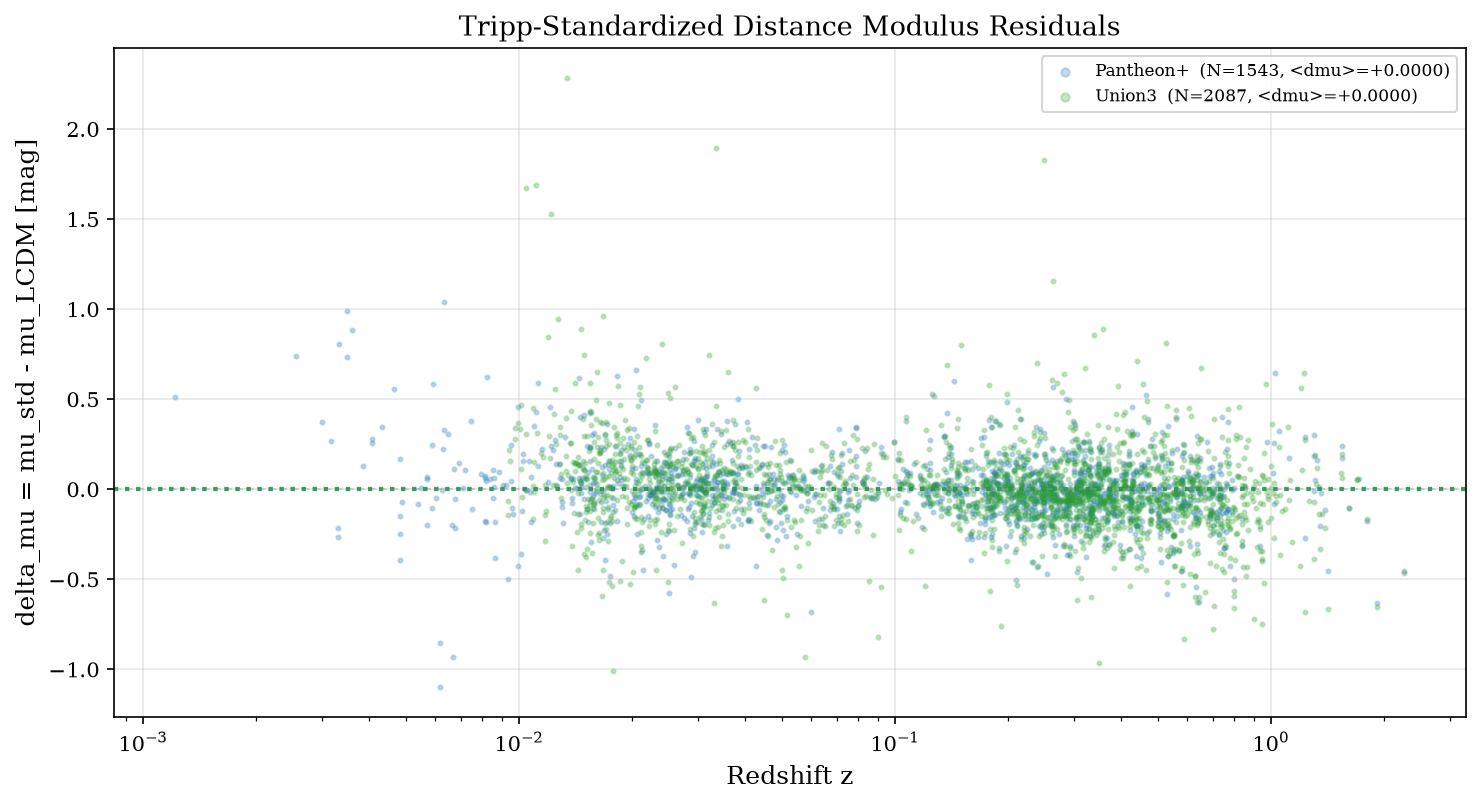

In [40]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.axhline(0, color="gray", ls="--", alpha=0.3, lw=1)

ax.scatter(pan["z"], pan["delta_mu"], s=4, alpha=0.25, c=C_PAN,
           label=f"Pantheon+  (N={len(pan)}, <dmu>={pan['delta_mu'].mean():+.4f})",
           rasterized=True)
ax.scatter(u3["z"], u3["delta_mu"], s=4, alpha=0.25, c=C_U3,
           label=f"Union3  (N={len(u3)}, <dmu>={u3['delta_mu'].mean():+.4f})",
           rasterized=True)

ax.axhline(pan["delta_mu"].mean(), color=C_PAN, ls=":", lw=2, alpha=0.7)
ax.axhline(u3["delta_mu"].mean(), color=C_U3, ls=":", lw=2, alpha=0.7)

ax.set_xlabel("Redshift z")
ax.set_ylabel("delta_mu = mu_std - mu_LCDM [mag]")
ax.set_title("Tripp-Standardized Distance Modulus Residuals")
ax.set_xscale("log")
ax.legend(fontsize=8, markerscale=2)

fig.tight_layout()
plt.show()

## Common Standardization (Shared $\alpha, \beta$)

Now compute $\mu^*$ using the **same** fitted $\alpha, \beta$ for both surveys, allowing only $M_B$ to differ per survey. This tests whether cross-survey offsets come from calibration differences (captured by $M_B$) or from different standardization slopes.

We use the **global-fit** $\alpha, \beta$ (fitted jointly to all data).

COMMON STANDARDIZATION (shared alpha, beta)
Fixed alpha = 0.1234, beta = 2.3725

Survey             M_B    <dmu*> std(dmu*)
  ---------------------------------------
Pantheon+     -19.3223   +0.0000    0.1840
Union3        -19.0661   -0.0000    0.2362

Comparison with independent fit (different alpha,beta per survey):
  Pantheon+     std(indep)=0.1825  std(common)=0.1840  diff=+0.0015
  Union3        std(indep)=0.2357  std(common)=0.2362  diff=+0.0005


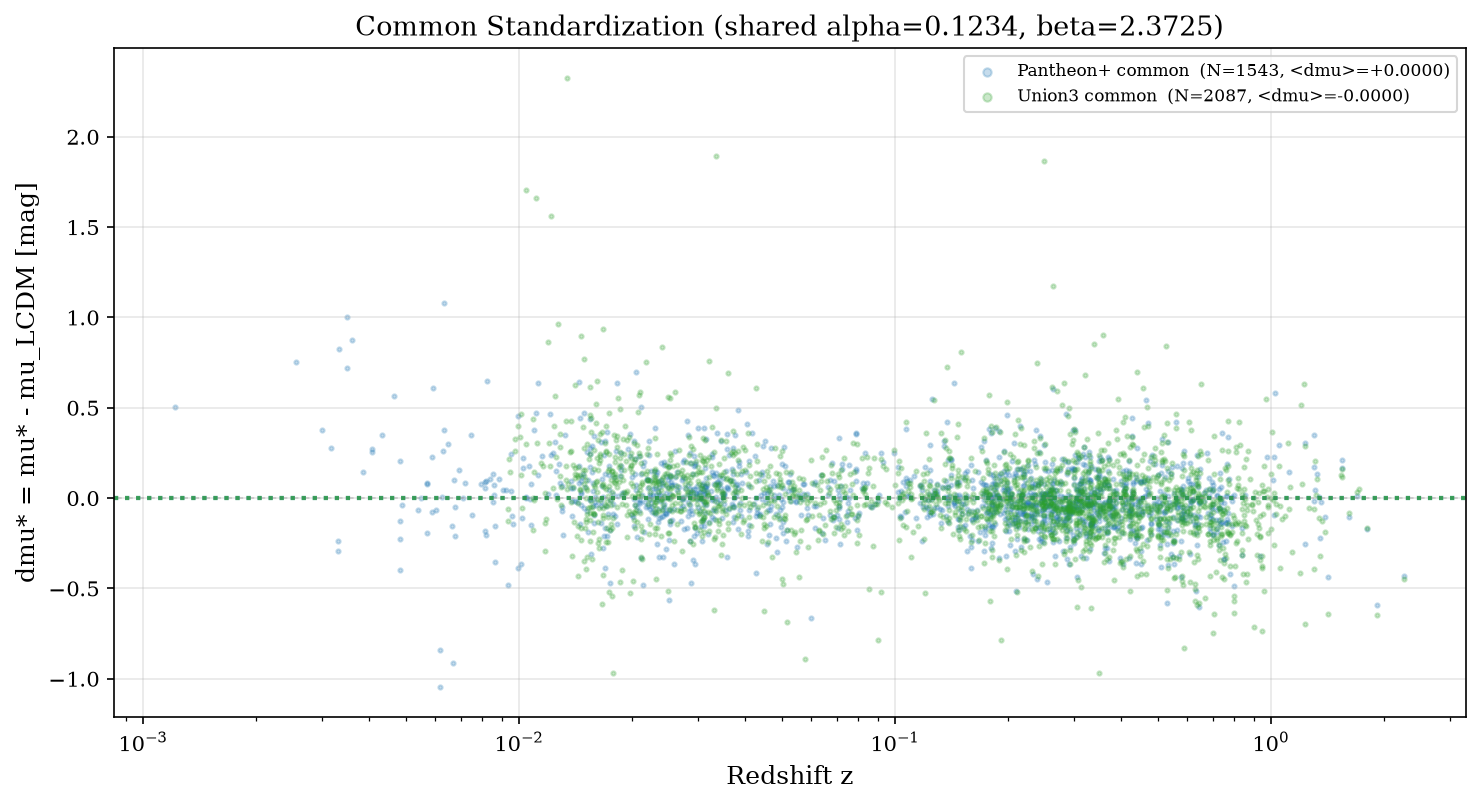

Common-std binned <Delta_mu*> = -0.0041 +/- 0.0063 mag  (Pantheon+ - Union3)


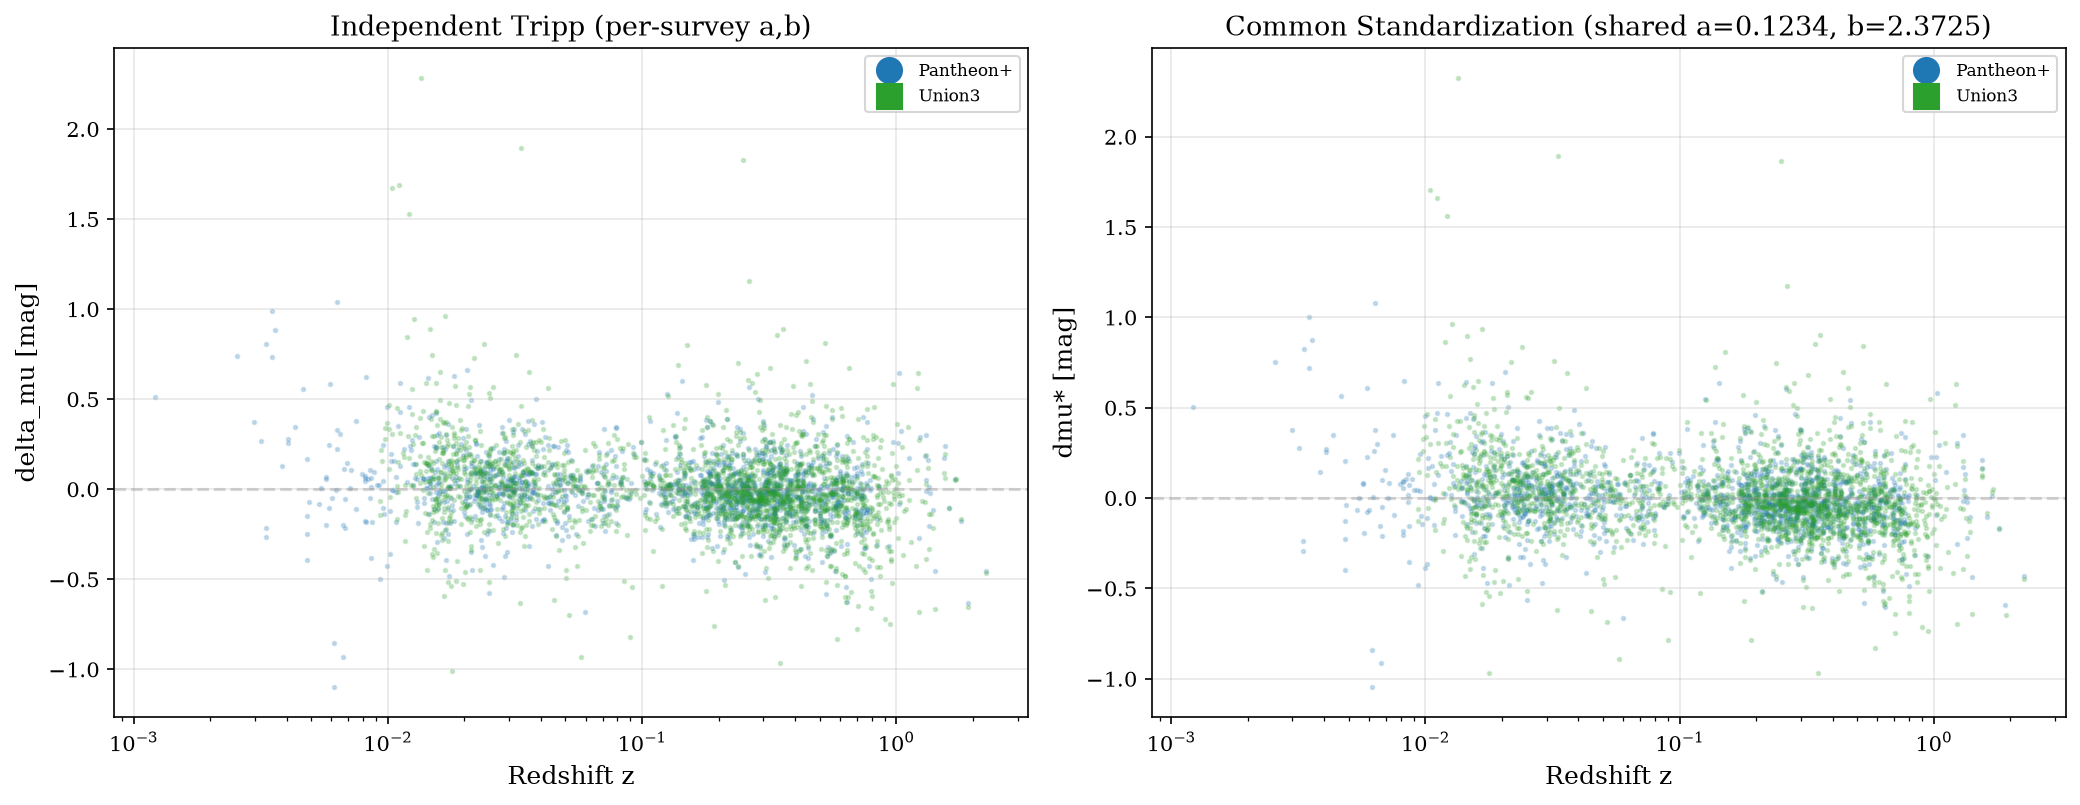

In [41]:
# Reuse binning helper from earlier (defined here so this cell is self-contained)
def _bin_stats(sub, bins):
    labels, means, sems, counts = [], [], [], []
    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i + 1]
        mask = (sub["z"] >= lo) & (sub["z"] < hi)
        vals = sub.loc[mask, "delta_mu"].dropna()
        if len(vals) < 3:
            labels.append(f"{lo:.3f}-{hi:.3f}")
            means.append(np.nan); sems.append(np.nan); counts.append(0)
        else:
            labels.append(f"{lo:.3f}-{hi:.3f}")
            means.append(vals.mean()); sems.append(vals.std() / np.sqrt(len(vals))); counts.append(len(vals))
    return np.array(labels), np.array(means), np.array(sems), np.array(counts)

z_min = max(pan["z"].min(), u3["z"].min()) + 0.001
z_max = min(pan["z"].max(), u3["z"].max())
_bins = np.geomspace(z_min, z_max, 16)

# Global-fit alpha, beta from joint fit
alpha_global = d["alpha_fit"]    # 0.1234
beta_global  = d["beta_fit"]     # 2.3725

# Fit M_B per survey with fixed alpha, beta:
# M_S = mean( mB - mu_LCDM + alpha*x1 - beta*c )  for survey S
def fit_M_fixed_ab(sub, alpha, beta):
    v = sub["mB"] - sub["mu_model"] + alpha * sub["x1"] - beta * sub["c"]
    return v.mean()

M_pan_star = fit_M_fixed_ab(pan, alpha_global, beta_global)
M_u3_star  = fit_M_fixed_ab(u3,  alpha_global, beta_global)

# Standardized mu* and residuals
pan["mu_star"] = pan["mB"] - M_pan_star + alpha_global * pan["x1"] - beta_global * pan["c"]
pan["dmu_star"] = pan["mu_star"] - pan["mu_model"]

u3["mu_star"] = u3["mB"] - M_u3_star + alpha_global * u3["x1"] - beta_global * u3["c"]
u3["dmu_star"] = u3["mu_star"] - u3["mu_model"]

print("=" * 60)
print("COMMON STANDARDIZATION (shared alpha, beta)")
print("=" * 60)
print(f"Fixed alpha = {alpha_global:.4f}, beta = {beta_global:.4f}")
print()
print(f"{'Survey':12s} {'M_B':>9s} {'<dmu*>':>9s} {'std(dmu*)':>9s}")
print("  " + "-" * 39)
for name, dat in [("Pantheon+", pan), ("Union3", u3)]:
    v = dat["dmu_star"]
    print(f"{name:12s} {M_pan_star if name == 'Pantheon+' else M_u3_star:>+9.4f} "
          f"{v.mean():>+9.4f} {v.std():>9.4f}")
print()
print("Comparison with independent fit (different alpha,beta per survey):")
for name, dat, M_ind, a_ind, b_ind in [
    ("Pantheon+", pan, M_pan, a_pan, b_pan),
    ("Union3", u3, M_u3, a_u3, b_u3)]:
    v_ind = dat["delta_mu"]
    v_com = dat["dmu_star"]
    print(f"  {name:12s}  std(indep)={v_ind.std():.4f}  std(common)={v_com.std():.4f}  "
          f"diff={v_com.std() - v_ind.std():+.4f}")

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axhline(0, color="gray", ls="--", alpha=0.3, lw=1)
ax.scatter(pan["z"], pan["dmu_star"], s=4, alpha=0.25, c=C_PAN,
           label=f"Pantheon+ common  (N={len(pan)}, <dmu>={pan['dmu_star'].mean():+.4f})",
           rasterized=True)
ax.scatter(u3["z"], u3["dmu_star"], s=4, alpha=0.25, c=C_U3,
           label=f"Union3 common  (N={len(u3)}, <dmu>={u3['dmu_star'].mean():+.4f})",
           rasterized=True)
ax.axhline(pan["dmu_star"].mean(), color=C_PAN, ls=":", lw=2, alpha=0.7)
ax.axhline(u3["dmu_star"].mean(), color=C_U3, ls=":", lw=2, alpha=0.7)
ax.set_xlabel("Redshift z")
ax.set_ylabel("dmu* = mu* - mu_LCDM [mag]")
ax.set_title("Common Standardization (shared alpha={:.4f}, beta={:.4f})".format(alpha_global, beta_global))
ax.set_xscale("log")
ax.legend(fontsize=8, markerscale=2)
fig.tight_layout()
plt.show()

# Binned common-standardization difference
_, mu_pan_bin_s, se_pan_bin_s, n_pan_s = _bin_stats(pan.assign(delta_mu=pan["dmu_star"]), _bins)
_, mu_u3_bin_s,  se_u3_bin_s,  n_u3_s  = _bin_stats(u3.assign(delta_mu=u3["dmu_star"]),  _bins)

dmu_bin_s = mu_pan_bin_s - mu_u3_bin_s
dmu_err_s = np.sqrt(se_pan_bin_s**2 + se_u3_bin_s**2)

valid_s = np.isfinite(dmu_bin_s)
if valid_s.sum() > 0:
    wmean_s = np.sum(dmu_bin_s[valid_s] / dmu_err_s[valid_s]**2) / np.sum(1 / dmu_err_s[valid_s]**2)
    wstd_s = np.sqrt(1 / np.sum(1 / dmu_err_s[valid_s]**2))
    print(f"Common-std binned <Delta_mu*> = {wmean_s:+.4f} +/- {wstd_s:.4f} mag  (Pantheon+ - Union3)")

# Comparison plot: independent vs common
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
# Left: independent fit residuals
ax = axes[0]
ax.axhline(0, color="gray", ls="--", alpha=0.3)
ax.scatter(pan["z"], pan["delta_mu"], s=3, alpha=0.2, c=C_PAN, rasterized=True)
ax.scatter(u3["z"], u3["delta_mu"], s=3, alpha=0.2, c=C_U3, rasterized=True)
ax.set_xscale("log")
ax.set_xlabel("Redshift z")
ax.set_ylabel("delta_mu [mag]")
ax.set_title("Independent Tripp (per-survey a,b)")
ax.legend([plt.Line2D([0],[0],color=C_PAN, marker="o", ls=""),
           plt.Line2D([0],[0],color=C_U3, marker="s", ls="")],
          ["Pantheon+", "Union3"], fontsize=8, markerscale=2)
# Right: common standardization
ax = axes[1]
ax.axhline(0, color="gray", ls="--", alpha=0.3)
ax.scatter(pan["z"], pan["dmu_star"], s=3, alpha=0.2, c=C_PAN, rasterized=True)
ax.scatter(u3["z"], u3["dmu_star"], s=3, alpha=0.2, c=C_U3, rasterized=True)
ax.set_xscale("log")
ax.set_xlabel("Redshift z")
ax.set_ylabel("dmu* [mag]")
ax.set_title("Common Standardization (shared a={:.4f}, b={:.4f})".format(alpha_global, beta_global))
ax.legend([plt.Line2D([0],[0],color=C_PAN, marker="o", ls=""),
           plt.Line2D([0],[0],color=C_U3, marker="s", ls="")],
          ["Pantheon+", "Union3"], fontsize=8, markerscale=2)
fig.tight_layout()
plt.show()

## $\mu^*$ vs Redshift (Common-Standardized Hubble Diagram)

The common-standardized distance modulus $\mu^* = m_B - M_B + \alpha x_1 - \beta c$ using shared $(\alpha, \beta)$ from the global fit, with per-survey $M_B$.

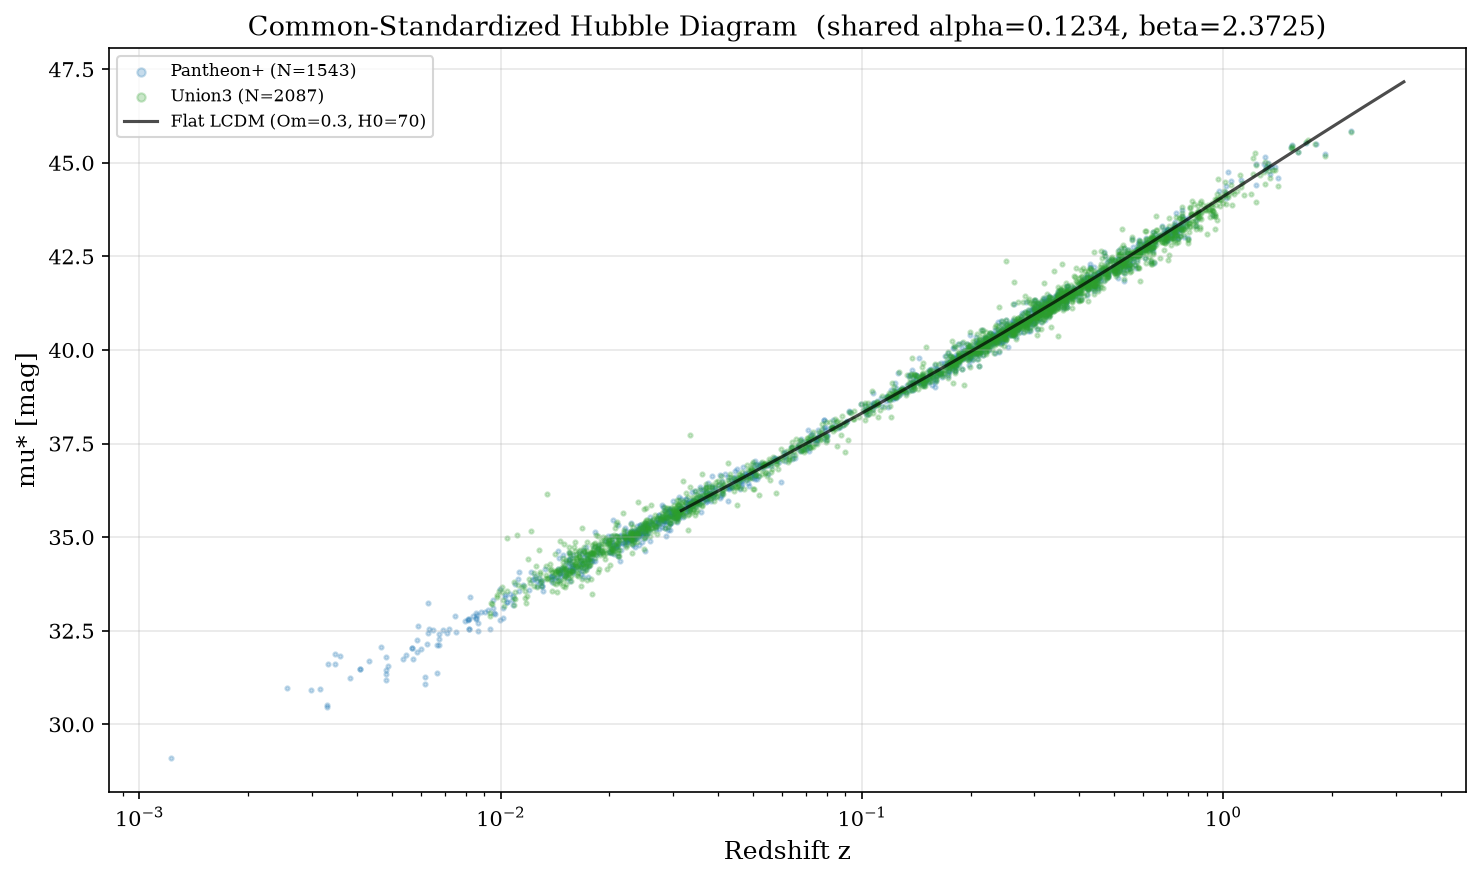

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(pan["z"], pan["mu_star"], s=4, alpha=0.25, c=C_PAN,
           label=f"Pantheon+ (N={len(pan)})", rasterized=True)
ax.scatter(u3["z"], u3["mu_star"], s=4, alpha=0.25, c=C_U3,
           label=f"Union3 (N={len(u3)})", rasterized=True)

z_curve = np.logspace(-1.5, 0.5, 200)
mu_lcdm = cosmo.distmod(z_curve).value
ax.plot(z_curve, mu_lcdm, "k-", lw=1.5, alpha=0.7, label="Flat LCDM (Om=0.3, H0=70)")

ax.set_xscale("log")
ax.set_xlabel("Redshift z")
ax.set_ylabel("mu* [mag]")
ax.set_title("Common-Standardized Hubble Diagram  (shared alpha={:.4f}, beta={:.4f})".format(alpha_global, beta_global))
ax.legend(fontsize=8, markerscale=2)
fig.tight_layout()
plt.show()

## Binned Comparison

Bin both surveys into common redshift bins and compute $\Delta\mu_{\rm bin} = \langle\delta\mu\rangle_{\rm Pan} - \langle\delta\mu\rangle_{\rm U3}$ per bin, with propagated standard error.

In [43]:
NBINS = 15
z_min = max(pan["z"].min(), u3["z"].min()) + 0.001
z_max = min(pan["z"].max(), u3["z"].max())

bins = np.geomspace(z_min, z_max, NBINS + 1)

def bin_stats(sub, bins):
    labels = []
    means = []
    sems = []
    counts = []
    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i + 1]
        mask = (sub["z"] >= lo) & (sub["z"] < hi)
        vals = sub.loc[mask, "delta_mu"].dropna()
        if len(vals) < 3:
            labels.append(f"{lo:.3f}-{hi:.3f}")
            means.append(np.nan)
            sems.append(np.nan)
            counts.append(0)
        else:
            labels.append(f"{lo:.3f}-{hi:.3f}")
            means.append(vals.mean())
            sems.append(vals.std() / np.sqrt(len(vals)))
            counts.append(len(vals))
    return np.array(labels), np.array(means), np.array(sems), np.array(counts)

bin_labels, mu_pan_bin, se_pan_bin, n_pan = bin_stats(pan, bins)
_,         mu_u3_bin,  se_u3_bin,  n_u3  = bin_stats(u3,  bins)

bin_centers = np.sqrt(bins[:-1] * bins[1:])

dmu_bin = mu_pan_bin - mu_u3_bin
dmu_err = np.sqrt(se_pan_bin**2 + se_u3_bin**2)

print("=" * 80)
print("BINNED DELTA-MU: Pantheon+ minus Union3")
print("=" * 80)
print(f"{'z_range':>15s}  {'z_mid':>7s}  {'dmu':>8s}  {'dmu_err':>8s}  "
      f"{'N_Pan':>6s}  {'N_U3':>6s}")
print("  " + "-" * 56)
for i in range(len(bin_labels)):
    if np.isfinite(dmu_bin[i]):
        print(f"{bin_labels[i]:>15s}  {bin_centers[i]:>7.4f}  {dmu_bin[i]:>+8.4f}  "
              f"{dmu_err[i]:>8.4f}  {n_pan[i]:>6d}  {n_u3[i]:>6d}")
    else:
        print(f"{bin_labels[i]:>15s}  {bin_centers[i]:>7.4f}  {'--':>8s}  "
              f"{'--':>8s}  {n_pan[i]:>6d}  {n_u3[i]:>6d}")

valid = np.isfinite(dmu_bin)
if valid.sum() > 0:
    wmean = np.sum(dmu_bin[valid] / dmu_err[valid]**2) / np.sum(1 / dmu_err[valid]**2)
    wstd = np.sqrt(1 / np.sum(1 / dmu_err[valid]**2))
    print(f"  {'Weighted mean:':>15s}  {'':>7s}  {wmean:>+8.4f} +/- {wstd:.4f}")
    print(f"  {'Unweighted mean:':>15s}  {'':>7s}  {np.mean(dmu_bin[valid]):>+8.4f} +/- {np.std(dmu_bin[valid]):.4f}")

BINNED DELTA-MU: Pantheon+ minus Union3
        z_range    z_mid       dmu   dmu_err   N_Pan    N_U3
  --------------------------------------------------------
    0.010-0.015   0.0124   -0.1384    0.0692      42      62
    0.015-0.021   0.0177   -0.0121    0.0291      90     183
    0.021-0.030   0.0254   -0.0559    0.0200     142     148
    0.030-0.043   0.0363   -0.0240    0.0258     111     133
    0.043-0.062   0.0520   +0.0373    0.0290      69      83
    0.062-0.089   0.0745   +0.0165    0.0266      50      77
    0.089-0.128   0.1067   +0.0460    0.0324      47      64
    0.128-0.183   0.1529   -0.0145    0.0210     118     140
    0.183-0.262   0.2189   -0.0104    0.0159     221     254
    0.262-0.375   0.3135   +0.0017    0.0145     248     343
    0.375-0.537   0.4490   -0.0119    0.0184     157     252
    0.537-0.769   0.6430   +0.0404    0.0209     137     207
    0.769-1.102   0.9208   +0.0871    0.0749      17     100
    1.102-1.578   1.3187   +0.0681    0.0885   

## Plot B: $\Delta\mu$ vs Redshift

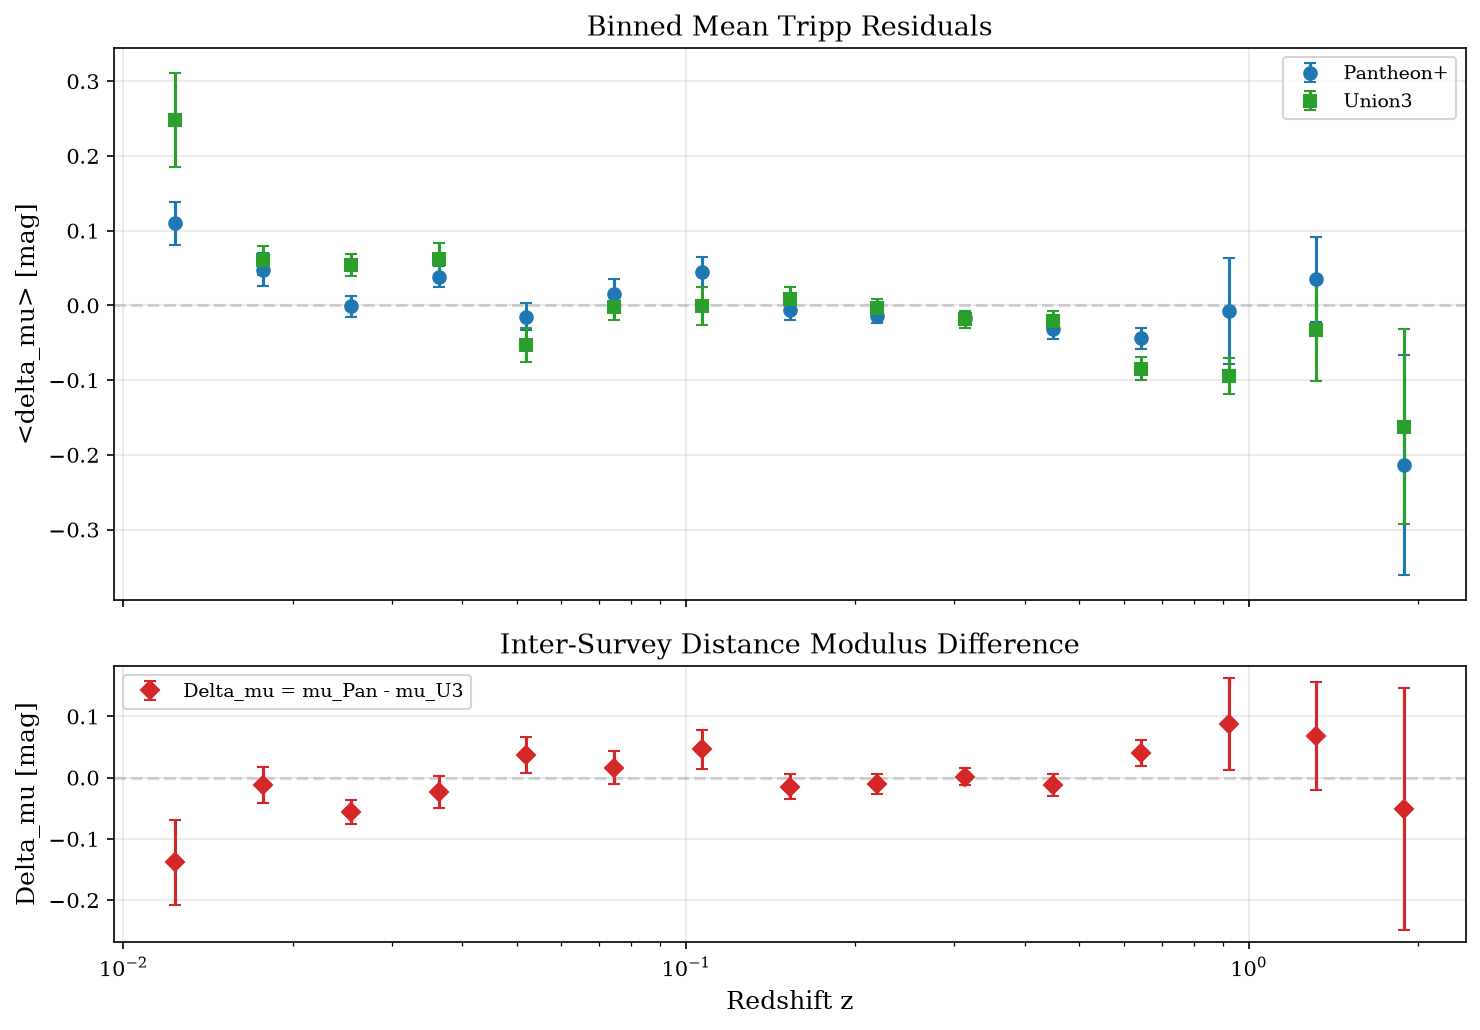

In [44]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7),
                         gridspec_kw={"height_ratios": [2, 1]}, sharex=True)

# Top: binned delta-mu for each survey
ax1.axhline(0, color="gray", ls="--", alpha=0.3)
ax1.errorbar(bin_centers, mu_pan_bin, yerr=se_pan_bin,
             fmt="o", color=C_PAN, ms=6, capsize=3, label="Pantheon+")
ax1.errorbar(bin_centers, mu_u3_bin, yerr=se_u3_bin,
             fmt="s", color=C_U3, ms=6, capsize=3, label="Union3")
ax1.set_xscale("log")
ax1.set_ylabel("<delta_mu> [mag]")
ax1.set_title("Binned Mean Tripp Residuals")
ax1.legend(fontsize=9)

# Bottom: Delta-mu (Pantheon+ - Union3)
ax2.axhline(0, color="gray", ls="--", alpha=0.3)
valid = np.isfinite(dmu_bin)
ax2.errorbar(bin_centers[valid], dmu_bin[valid], yerr=dmu_err[valid],
             fmt="D", color="#d62728", ms=6, capsize=3,
             label="Delta_mu = mu_Pan - mu_U3")
ax2.set_xlabel("Redshift z")
ax2.set_ylabel("Delta_mu [mag]")
ax2.set_xscale("log")
ax2.set_title("Inter-Survey Distance Modulus Difference")
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Summary

In [45]:
print("=" * 65)
print("SUMMARY: Tripp Standardization — Pantheon+ vs Union3")
print("=" * 65)
print()
print("Tripp fit parameters:")
print(f"  {'':20s} {'M_B':>9s} {'alpha':>8s} {'beta':>8s} {'std(resid)':>11s}")
print(f"  {'-'*56}")
print(f"  {'Pantheon+':20s} {M_pan:>+9.4f} {a_pan:>+8.4f} {b_pan:>+8.4f} {r_pan:>11.4f}")
print(f"  {'Union3':20s}    {M_u3:>+9.4f} {a_u3:>+8.4f} {b_u3:>+8.4f} {r_u3:>11.4f}")
print()
print("Residual statistics (delta_mu = mu_std - mu_LCDM):")
print(f"  {'':20s} {'<dmu>':>9s} {'std':>8s} {'MAD':>8s} {'N':>6s}")
print(f"  {'-'*51}")
for name, dat in [("Pantheon+", pan), ("Union3", u3)]:
    v = dat["delta_mu"].dropna()
    print(f"  {name:20s} {v.mean():>+9.4f} {v.std():>8.4f} {mad(v):>8.4f} {len(v):>6d}")
print()
print("Binned inter-survey difference (weighted mean across bins):")
if valid.sum() > 0:
    print(f"  <Delta_mu> = {wmean:+.4f} +/- {wstd:.4f} mag  (Pantheon+ - Union3)")
print()
print("Common standardization (shared alpha={:.4f}, beta={:.4f}):".format(d['alpha_fit'], d['beta_fit']))
print(f"  {'':20s} {'M_B':>9s} {'<dmu*>':>9s} {'std(dmu*)':>9s}")
print(f"  {'-'*47}")
print(f"  {'Pantheon+':20s} {M_pan_star:>+9.4f} {pan['dmu_star'].mean():>+9.4f} {pan['dmu_star'].std():>9.4f}")
print(f"  {'Union3':20s}    {M_u3_star:>+9.4f} {u3['dmu_star'].mean():>+9.4f} {u3['dmu_star'].std():>9.4f}")
if valid_s.sum() > 0:
    print(f"  <Delta_mu*> (common) = {wmean_s:+.4f} +/- {wstd_s:.4f} mag")


SUMMARY: Tripp Standardization — Pantheon+ vs Union3

Tripp fit parameters:
                             M_B    alpha     beta  std(resid)
  --------------------------------------------------------
  Pantheon+             -19.3190  +0.1383  +2.5703      0.1824
  Union3                   -19.0661  +0.1180  +2.5248      0.2356

Residual statistics (delta_mu = mu_std - mu_LCDM):
                           <dmu>      std      MAD      N
  ---------------------------------------------------
  Pantheon+              +0.0000   0.1825   0.0935   1543
  Union3                 +0.0000   0.2357   0.1124   2087

Binned inter-survey difference (weighted mean across bins):
  <Delta_mu> = -0.0037 +/- 0.0063 mag  (Pantheon+ - Union3)

Common standardization (shared alpha=0.1234, beta=2.3725):
                             M_B    <dmu*> std(dmu*)
  -----------------------------------------------
  Pantheon+             -19.3223   +0.0000    0.1840
  Union3                   -19.0661   -0.0000    0.2362
